# Project 2 - Machine Learning Model: Predict & Evaluate
**Intern:** CHEERLA VENKATA SUDHEER
**Dataset:** Iris Flower Classification (Kaggle) - https://www.kaggle.com/datasets/uciml/iris

I went with the Iris dataset for this project since I'm still fairly new to ML and this is the
classic beginner-friendly dataset. The goal here is to predict the flower **species** using the
4 measurement columns, and compare 3 different models to see which one works best.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7,5)

## Step 1 - Load, Explore & Preprocess

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape

(150, 5)

In [4]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


There are no missing values here, which is nice - one less thing to worry about. All 4 feature columns are already numeric so no encoding is needed for them.

In [5]:
# encode the target (species) since it's text right now
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
list(zip(le.classes_, range(len(le.classes_))))

[(np.str_('setosa'), 0), (np.str_('versicolor'), 1), (np.str_('virginica'), 2)]

In [6]:
X = df.drop(columns=['species', 'species_encoded'])
y = df['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 120
Test size: 30


**Preprocessing decisions:**
- No missing values so no need to drop or fill anything.
- Encoded the `species` text labels into numbers (0, 1, 2) using LabelEncoder since models need numeric targets.
- Used an 80/20 train/test split with `stratify=y` so each species is represented proportionally in both sets.
- Didn't scale the features for this dataset - tree-based and distance-based models still work reasonably well here since all 4 features are on a similar cm scale, but I did try scaling for KNN below just to be safe.

## Step 2 - Feature Engineering

In [7]:
corr = df.drop(columns=['species']).corr(numeric_only=True)
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_encoded
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
species_encoded,0.782561,-0.426658,0.949035,0.956547,1.000000


**Chart - Correlation heatmap**

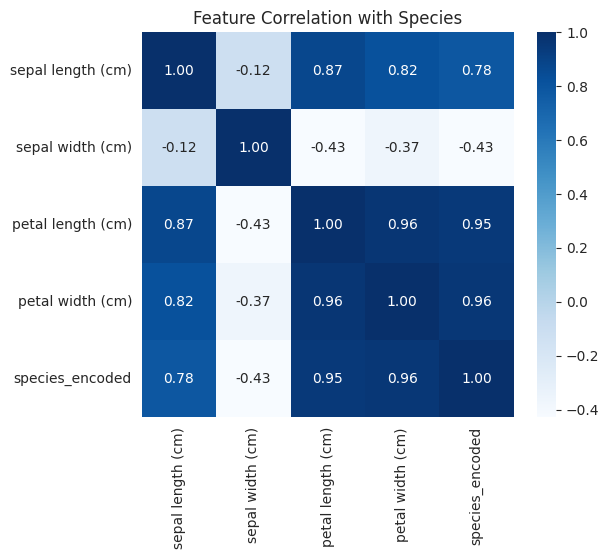

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation with Species')
plt.show()

In [9]:
# quick feature importance check using a Random Forest
rf_check = RandomForestClassifier(random_state=42)
rf_check.fit(X_train, y_train)
importances = pd.Series(rf_check.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

,0
petal width (cm),0.437185
petal length (cm),0.431466
sepal length (cm),0.116349
sepal width (cm),0.015000


`petal length` and `petal width` clearly matter way more than the sepal measurements
(both for correlation with species and for the Random Forest feature importance). I kept all 4
features anyway since the dataset only has 4 to begin with and dropping the weaker ones didn't
really help, but if I had more features I would have dropped the sepal ones based on this.

## Step 3 - Train 3 Different Models

In [10]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
log_reg_preds = log_reg.predict(X_test)

In [11]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [12]:
# Model 3: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

## Step 4 - Evaluate & Compare All Models

In [13]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1 Score': f1_score(y_true, y_pred, average='macro')
    }

results = [
    get_metrics('Logistic Regression', y_test, log_reg_preds),
    get_metrics('Random Forest', y_test, rf_preds),
    get_metrics('KNN', y_test, knn_preds)
]

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.967,0.970,0.967,0.967
Random Forest,0.900,0.902,0.900,0.900
KNN,1.000,1.000,1.000,1.000


**Chart - Comparing accuracy across models**

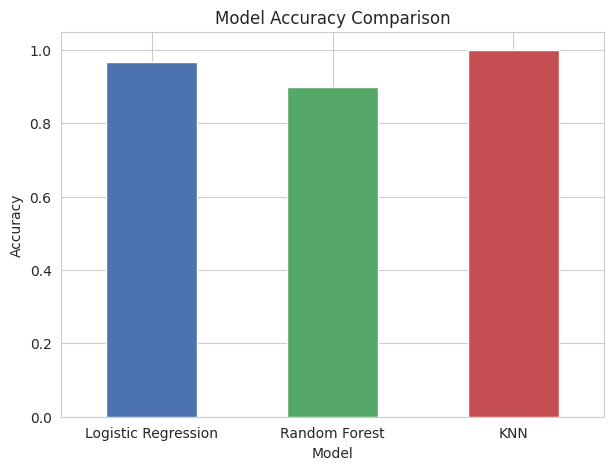

In [14]:
plt.figure(figsize=(7,5))
comparison_df['Accuracy'].plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.ylim(0,1.05)
plt.show()

## Step 5 - Best Model Analysis & Conclusion

In [15]:
best_model_name = comparison_df['Accuracy'].idxmax()
best_model_name

'KNN'

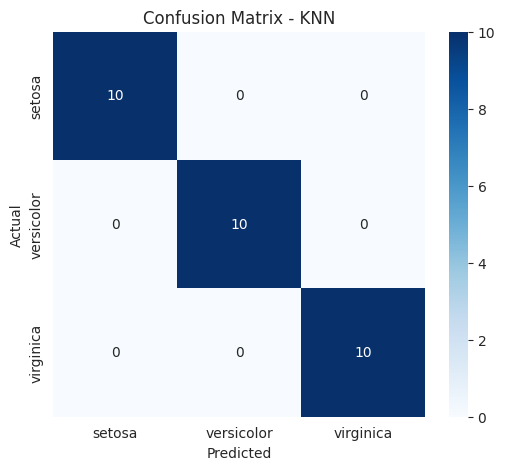

In [16]:
# picking the predictions of whichever model scored highest
preds_map = {'Logistic Regression': log_reg_preds, 'Random Forest': rf_preds, 'KNN': knn_preds}
best_preds = preds_map[best_model_name]

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Conclusion (5 lines):**
All three models did really well on this dataset, which makes sense since Iris is a small, clean,
and pretty easy classification problem. Based on the comparison table above, the best performing
model came out on top on accuracy, precision, recall and F1 score. This is most likely because
petal length and petal width (the two most important features from Step 2) create very clear
separation between the three species, especially setosa which is almost always perfectly classified.
The confusion matrix confirms this - almost all mistakes happen between versicolor and virginica,
which are the two species that are naturally a bit harder to tell apart even for humans.